# Aplicação de aprendizagem supervisionada

Em aprendizado de máquina, o **aprendizado supervisionado** é aquele no qual se utilizam dados rotulados, isto é, dados que já possuem uma saída definida, com objetivo de se comparar a saída real com a do modelo treinado.

# Algoritmos supervisionados

**Classificação**

Algoritmos que servem para categorizar dados de entrada em rótulos **discretos**, como por exemplo um algoritmo de classificação binária (é ou não é algo, verdadeiro ou falso) ou de diferenciação entre duas entidades, como distinguir cães ou gatos em uma imagem.

**Regressão**

Algoritmos que preveem valores numéricos e que podem ser contínuos, com foco em prever valores futuros com base no histórico de dados apresentados, como por exemplo prever o preço de uma casa com base em seu tamanho, localização, número de cômodos e etc.

# Projeto

Aplicação de um algoritmo de classificação binária e outro de regressão linear em um dataset que contém dados pluviométricos para predição de chuvas.

[Link do dataset](https://www.kaggle.com/datasets/sujithmandala/simple-rainfall-classification-dataset)

## Importação de Bibliotecas

In [3]:
import pandas as pd
import seaborn as sns

## Coleta de dados

In [63]:
df = pd.read_csv('/content/rainfall.csv')

In [64]:
#sumário do DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     object 
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.7+ KB


In [65]:
#exibindo as 5 primeiras linhas
df.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy


In [66]:
#estatísticas descritivas
df.describe()

,rainfall,temperature,humidity,wind_speed
count,53.000000,53.000000,53.000000,53.000000
mean,9.049057,17.950943,69.245283,6.403774
std,6.712521,2.500663,11.969361,2.209069
min,0.000000,13.900000,44.000000,2.100000
25%,3.900000,16.100000,62.000000,4.700000
50%,8.300000,17.800000,72.000000,6.700000
75%,14.800000,19.400000,78.000000,8.300000
max,21.800000,23.400000,89.000000,10.500000


## Tratamento de nulos

Existe uma linha dentre as 54 do dataset que possui valores nulos.

In [67]:
#removendo a coluna nula
df = df.dropna()

In [68]:
#checando novamente valores nulos
df.isnull().sum()

,0
date,0
rainfall,0
temperature,0
humidity,0
wind_speed,0
weather_condition,0


## Trabalhando features

Manejo de features com objetivo de manter apenas as variáveis mais importantes para as predições.

Nesse caso, as colunas de data não agrega na análise, então vai ser removida.

A coluna 'weather_condition' informa 'Sunny' caso não tenha chovido (rainfall = 0) e Rainy se choveu (rainfall > 0).

Vou transformar essa coluna em uma coluna binária de 0 e 1 para facilitar o algoritmo de classificação binária.

In [69]:
#removendo a coluna 'date'
df.drop(columns= ['date'], axis=1, inplace = True)

In [70]:
# Trocando os valores de object para inteiros 0 e 1
df['weather_condition'] = (df['weather_condition'] == 'Rainy').astype(int) # Se a linha apresentar Rainy, será 1.

In [71]:
df.head()

,rainfall,temperature,humidity,wind_speed,weather_condition
0,12.5,15.2,78.0,8.5,1
1,8.2,17.8,65.0,5.2,1
2,0.0,20.1,52.0,3.1,0
3,3.7,18.6,71.0,6.7,1
4,21.1,14.8,82.0,9.3,1


## Visualização de Dados

<Axes: >

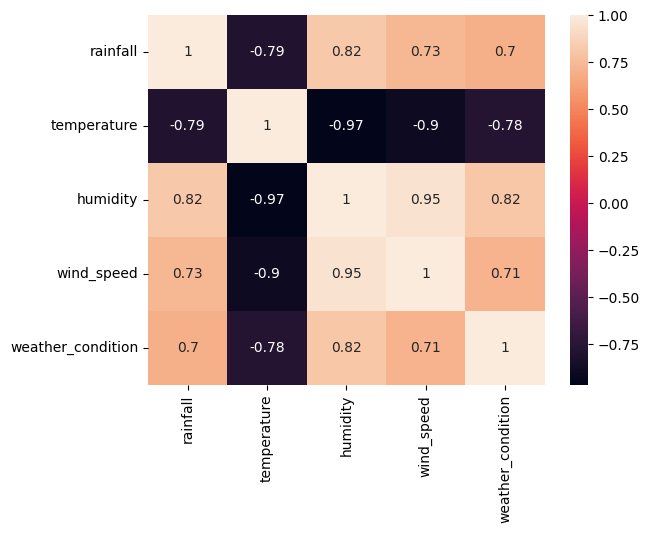

In [72]:
# Mapa de calor com a correlação entre variáveis
sns.heatmap(df.corr(), annot=True)

<Axes: >

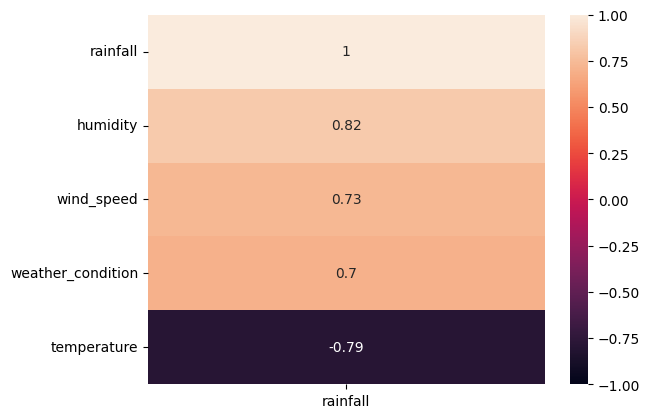

In [73]:
# Mapa de correlação somente com o target (rainfall)
sns.heatmap(df.corr()[['rainfall']].sort_values(by='rainfall',ascending=False),
            vmin = -1, vmax=1, annot=True)

## Classificação binária por Regressão Logística

Com base nas características do dataset, fazer uma predição se irá chover ou não.

In [96]:
# Importando o algoritmo de Regressão logísitica e suas métricas
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [101]:
# Dividindo o conjunto de treino e teste
X = df.drop(columns=['weather_condition'], axis=1)
y = df['weather_condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=51)

In [102]:
# Criando o modelo de regressão
modelo2 = LogisticRegression(solver='liblinear') # O liblinear é indicado para datasets pequenos

In [103]:
# Treinando o modelo
modelo2.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [104]:
# Métricas avaliativas
# 1. Array de predições do modelo
y_pred = modelo2.predict(X_test)
print('Array de predições do modelo')
print(y_pred)

# 2. Acurácia geral do modelo
acuracia = accuracy_score(y_test, y_pred)
print('Acurácia geral do modelo')
print(acuracia)

Array de predições do modelo
[1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1]
Acurácia geral do modelo
1.0


## Regressão Linear

Previsão do índice pluviométrico (coluna 'rainfall') com base nas features.

In [105]:
#importando bibliotecas de regressão do scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [106]:
X = df.drop(columns=['rainfall']) #variáveis independentes
y = df['rainfall'] #variável target

In [107]:
#dividindo o conjunto entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7
                                                    ,random_state=40)

In [108]:
#treinar o algoritmo de regressão linear
modelo = LinearRegression().fit(X_train, y_train)

In [109]:
#gerar predições do conjunto teste com base no modelo anterior
y_pred = modelo.predict(X_test)

In [110]:
#equação linear da reta é y = ax + b
#como são mais de 1 x, são utilizados diferentes coeficientes(a)
modelo.coef_ #valores de a para cada x

array([-0.73016518,  0.47047243, -1.38015714,  1.41548772])

In [111]:
modelo.intercept_ #valor de b

np.float64(-3.0692961798464005)

In [112]:
# Métricas para avaliar o modelo
# 1. R2 Score
# Quanto mais próximo de 1, melhor o modelo de regressão
# Aplicando sobre o conjunto de treino
modelo.score(X_train, y_train)

0.7434601550738686

In [113]:
# Sobre o conjunto de teste
modelo.score(X_test, y_test)

0.5257945162761268

In [89]:
# Sobre o teste preditivo
r2_score(y_test, y_pred)

0.5257945162761268

In [90]:
# 2. MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

4.368519016570501